# Predicting Hotel Booking Cancellations
**Capstone Assignment 20.1 - Initial Report and EDA**

Author: Siva Prasad Ampavatina

## 1. Business context and research question

Hotels live with a constant operational headache: a meaningful share of bookings end in cancellation, which leaves rooms empty unless the hotel overbooks to compensate. Overbook too aggressively and you walk a paying guest at check-in (a brand-damaging event). Overbook too cautiously and you run with avoidable empty rooms.

**Research question:** Which booking attributes most strongly predict whether a reservation will be canceled, and can we build a baseline model that revenue management could use to forecast cancellation risk at the booking level?

**Target variable:** `is_canceled` - 1 if the booking was canceled before check-in, 0 if the guest checked in.

**Why this dataset (pivot from earlier ideas):**
- The original Module 16 plan was a defect-prediction model on internal SIT/UAT bug-tracker data; that data could not be released by the company.
- A first pivot to the UCI Bank Marketing dataset was abandoned because Bank Marketing is used in standard course exercises and would not show fresh work.
- The Hotel Booking Demand dataset (Antonio, Almeida, Nunes 2019) is less commonly used in coursework, real-world, and asks the same shape of question as the original idea: predict an outcome so the team can plan resources.

## 2. Imports and setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42

# Resolve the deliverables/ root by walking up from CWD until we find data/.
# This keeps the notebook portable: it works whether it sits at the
# deliverables root or inside a notebooks/ subfolder.
HERE = Path.cwd()
for candidate in [HERE, HERE.parent, HERE.parent.parent]:
    if (candidate / 'data' / 'hotel_bookings.csv').exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        'Could not find deliverables/ root containing data/hotel_bookings.csv. '
        f'Searched from CWD={HERE}'
    )

DATA_PATH = ROOT / 'data' / 'hotel_bookings.csv'
IMAGES = ROOT / 'images'
IMAGES.mkdir(exist_ok=True)
print(f'Deliverables root: {ROOT}')
print(f'Data file exists: {DATA_PATH.exists()}')

Deliverables root: c:\Users\asiva\anaconda_projects\UCB-AIML\Capstone_Project\Module20-EDA
Data file exists: True


## 3. Data loading and first look

The dataset comes from Antonio, Almeida and Nunes (2019), *Hotel Booking Demand Datasets*, Data in Brief 22, pp. 41-49. It bundles bookings from one resort hotel and one city hotel in Portugal, covering arrivals from July 2015 to August 2017.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.dtypes.value_counts()

int64      16
str        12
float64     4
Name: count, dtype: int64

In [4]:
summary = df.describe(include='all').T
summary[['count', 'unique', 'top', 'freq', 'mean', 'std', 'min', 'max']].round(2).head(20)

,count,unique,top,freq,mean,std,min,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,55.0


### Target balance

37% of bookings are canceled - imbalanced but nowhere near as extreme as a typical fraud or churn problem. Accuracy is still a misleading metric here (a 'predict no cancel' baseline already scores 63%), so we will track ROC-AUC and the precision-recall curve instead.

             count  percent
is_canceled                
0            75166    62.96
1            44224    37.04


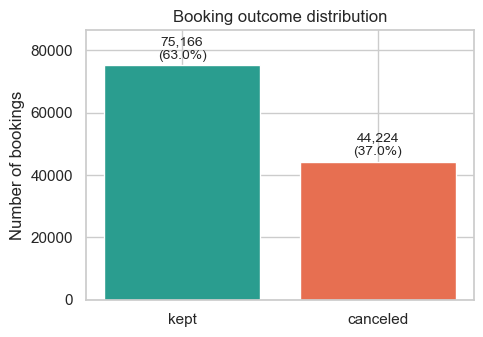

In [5]:
target_counts = df['is_canceled'].value_counts()
target_pct = df['is_canceled'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'count': target_counts, 'percent': target_pct}))

fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ['kept', 'canceled']
values = [target_counts.get(0, 0), target_counts.get(1, 0)]
ax.bar(labels, values, color=['#2a9d8f', '#e76f51'])
for i, v in enumerate(values):
    ax.text(i, v + len(df) * 0.01, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Booking outcome distribution')
ax.set_ylabel('Number of bookings')
ax.set_ylim(0, max(values) * 1.15)
plt.savefig(IMAGES / 'target_distribution.png')
plt.show()

## 4. Data cleaning

### 4.1 Duplicate bookings

The dataset has many bookings with identical attributes - same hotel, same dates, same room type, same agent. These look like genuine repeated reservations (a tour operator booking 20 identical rooms is common in this industry). We do *not* drop them - they are real transactions. We just confirm the count.

In [6]:
n_dup = df.duplicated().sum()
print(f'Exactly-duplicate rows: {n_dup:,} ({n_dup/len(df)*100:.1f}% of data)')
print('Keeping all rows - these are real repeated bookings, not data errors.')

Exactly-duplicate rows: 31,994 (26.8% of data)
Keeping all rows - these are real repeated bookings, not data errors.


### 4.2 Missing values

`company` is missing in 94% of rows because most bookings are not tied to a corporate account. `agent` is missing in 14%. `country` and `children` have small amounts. Each one needs a different fix.

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing': missing, 'percent': missing_pct})
missing_report = missing_report[missing_report['missing'] > 0].sort_values('missing', ascending=False)
print(missing_report)

          missing  percent
company    112593    94.31
agent       16340    13.69
country       488     0.41
children        4     0.00


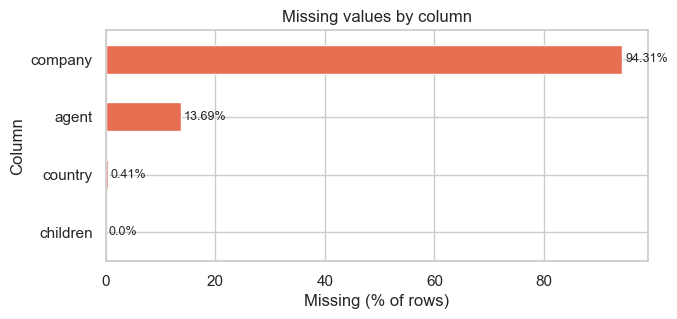

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
missing_report['percent'].plot(kind='barh', color='#e76f51', ax=ax)
ax.set_title('Missing values by column')
ax.set_xlabel('Missing (% of rows)')
ax.set_ylabel('Column')
ax.invert_yaxis()
for i, v in enumerate(missing_report['percent']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
plt.savefig(IMAGES / 'missing_values.png')
plt.show()

**Strategy per column:**

- `company`: drop the column entirely. With 94% missing it carries almost no signal as-is, and the few bookings with a company ID can still be identified by `customer_type='Contract'`.
- `agent`: replace missing with the literal `0` (meaning 'no agent, direct booking') and treat as a categorical bucket. Cardinality is too high for raw one-hot so we bucket later.
- `country`: replace missing with `'UNK'` and keep as a category. Bucketed later by frequency.
- `children`: only 4 rows missing. Impute with 0 (the modal value).

In [9]:
df = df.drop(columns=['company'])
df['agent'] = df['agent'].fillna(0).astype(int).astype(str)
df['country'] = df['country'].fillna('UNK')
df['children'] = df['children'].fillna(0).astype(int)
print('Remaining NaNs:', df.isna().sum().sum())

Remaining NaNs: 0


### 4.3 Impossible-value cleanup

Two real data errors:
- 180 bookings have zero guests (`adults + children + babies == 0`). Hotels do not host empty rooms; these are entry errors. Drop them.
- A handful of rows have `adr` (average daily rate) that is negative or absurdly high (the dataset documentation flags ~5400 EUR as a data entry error). We cap `adr` at the 99.9th percentile and drop the negative row.
- `meal = 'Undefined'` is documentation-confirmed to mean the same thing as `meal = 'SC'` (self-catered). Merge them.

In [10]:
before = len(df)
df = df.loc[(df['adults'] + df['children'] + df['babies']) > 0].copy()
print(f'Dropped {before - len(df)} bookings with zero guests.')

before = len(df)
df = df.loc[df['adr'] >= 0].copy()
print(f'Dropped {before - len(df)} booking(s) with negative adr.')

adr_cap = df['adr'].quantile(0.999)
n_capped = (df['adr'] > adr_cap).sum()
df['adr'] = df['adr'].clip(upper=adr_cap)
print(f'Capped {n_capped} booking(s) with adr > {adr_cap:.0f} EUR (99.9th pct).')

df['meal'] = df['meal'].replace({'Undefined': 'SC'})
print(f'Final shape after cleaning: {df.shape}')

Dropped 180 bookings with zero guests.
Dropped 1 booking(s) with negative adr.
Capped 120 booking(s) with adr > 326 EUR (99.9th pct).
Final shape after cleaning: (119209, 31)


## 5. Feature engineering

### 5.1 Leakage features - flag and exclude

`reservation_status` literally records whether the booking ended in Check-Out, Canceled, or No-Show. `reservation_status_date` is the date of that status change. Either one would let the model 'cheat' by looking at the answer. Both are kept in the dataframe for EDA but excluded from the model feature list.

In [11]:
print('reservation_status conditional on is_canceled:')
print(pd.crosstab(df['reservation_status'], df['is_canceled'],
                  margins=True))
print()
print('-> Check-Out maps perfectly to is_canceled=0;')
print('   Canceled and No-Show map perfectly to is_canceled=1.')
print('   Both columns excluded from the model feature list below.')

reservation_status conditional on is_canceled:
is_canceled             0      1     All
reservation_status                      
Canceled                0  42993   42993
Check-Out           75010      0   75010
No-Show                 0   1206    1206
All                 75010  44199  119209

-> Check-Out maps perfectly to is_canceled=0;
   Canceled and No-Show map perfectly to is_canceled=1.
   Both columns excluded from the model feature list below.


### 5.2 Derived numeric features

- `total_nights` = weekend + week nights
- `total_guests` = adults + children + babies
- `is_family` = booking includes children or babies
- `room_assigned_as_reserved` = 1 when the assigned room matches the reserved room. Mismatches often indicate a last-minute upgrade or downgrade and may correlate with cancellations.
- `arrival_date` parsed into a real datetime so we can sort and plot trends over time.
- `arrival_month_num` mapped from month name.

In [12]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['room_assigned_as_reserved'] = (
    df['reserved_room_type'] == df['assigned_room_type']
).astype(int)

month_map = {m: i for i, m in enumerate(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December'], 1)}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_month_num'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    errors='coerce',
)

df[['total_nights', 'total_guests', 'is_family',
    'room_assigned_as_reserved', 'arrival_month_num']].describe().round(2)

,total_nights,total_guests,is_family,room_assigned_as_reserved,arrival_month_num
count,119209.00,119209.00,119209.00,119209.00,119209.00
mean,3.43,1.97,0.08,0.88,6.55
std,2.54,0.72,0.27,0.33,3.09
min,0.00,1.00,0.00,0.00,1.00
25%,2.00,2.00,0.00,1.00,4.00
50%,3.00,2.00,0.00,1.00,7.00
75%,4.00,2.00,0.00,1.00,9.00
max,69.00,55.00,1.00,1.00,12.00


### 5.3 Bucket high-cardinality categoricals

- `country` has 177 unique values; we keep the top 15 plus a single `'OTHER'` bucket. This lets one-hot encoding stay manageable.
- `agent` is similar - keep the top 15 most frequent agent IDs, lump the rest as `'OTHER'`.

In [13]:
TOP_K = 15

top_countries = df['country'].value_counts().head(TOP_K).index
df['country_bucket'] = df['country'].where(df['country'].isin(top_countries), 'OTHER')

top_agents = df['agent'].value_counts().head(TOP_K).index
df['agent_bucket'] = df['agent'].where(df['agent'].isin(top_agents), 'OTHER')

print(f'country_bucket: {df["country_bucket"].nunique()} categories')
print(f'agent_bucket: {df["agent_bucket"].nunique()} categories')

country_bucket: 16 categories
agent_bucket: 16 categories


### 5.4 Define the model feature lists

These lists make the leakage exclusion explicit (`reservation_status`, `reservation_status_date`, and the raw `country`/`agent` are all kept out).

In [14]:
NUMERIC_FEATURES = [
    'lead_time',
    'arrival_month_num',
    'arrival_date_week_number',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'total_nights',
    'adults', 'children', 'babies', 'total_guests', 'is_family',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'room_assigned_as_reserved',
]

CATEGORICAL_FEATURES = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'deposit_type',
    'customer_type',
    'country_bucket',
    'agent_bucket',
]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f'Model features: {len(MODEL_FEATURES)} '
      f'({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)')

for leak in ['reservation_status', 'reservation_status_date', 'country', 'agent']:
    assert leak not in MODEL_FEATURES, f'{leak} must be excluded'
print('Leakage exclusion verified.')

Model features: 29 (20 numeric + 9 categorical)
Leakage exclusion verified.


## 6. Outlier analysis

We look at the numeric features that could carry extreme tails: `lead_time` (some bookings made hundreds of days in advance), `adr` (already capped at the 99.9th percentile during cleaning), `total_nights`, and `previous_cancellations`.

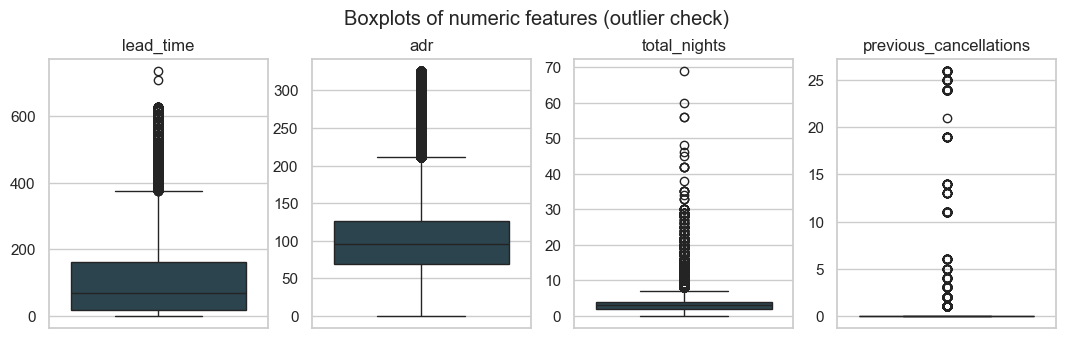

In [15]:
outlier_cols = ['lead_time', 'adr', 'total_nights', 'previous_cancellations']
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='#264653')
    ax.set_title(col)
    ax.set_ylabel('')
fig.suptitle('Boxplots of numeric features (outlier check)', y=1.02)
plt.savefig(IMAGES / 'outliers_boxplots.png')
plt.show()

In [16]:
def iqr_outlier_count(series: pd.Series) -> dict:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((series < lo) | (series > hi)).sum()
    return {'q1': q1, 'q3': q3, 'iqr': iqr, 'low': lo, 'high': hi,
            'n_outliers': n, 'pct': round(n / len(series) * 100, 2)}

summary = pd.DataFrame({c: iqr_outlier_count(df[c]) for c in outlier_cols}).T
print(summary)

                          q1     q3    iqr     low    high  n_outliers   pct
lead_time               18.0  161.0  143.0 -196.50  375.50      2981.0  2.50
adr                     69.5  126.0   56.5  -15.25  210.75      3864.0  3.24
total_nights             2.0    4.0    2.0   -1.00    7.00      5225.0  4.38
previous_cancellations   0.0    0.0    0.0    0.00    0.00      6479.0  5.43


**Decision:** keep all rows. The `lead_time` tail (bookings 700+ days out) is real corporate / group block behavior. `previous_cancellations` extremes are genuine: a guest with 26 prior cancellations is a strong signal worth keeping, not noise to discard. We rely on standard scaling to keep the linear model from being dominated by the long tails.

## 7. Univariate EDA

### 7.1 Numeric features

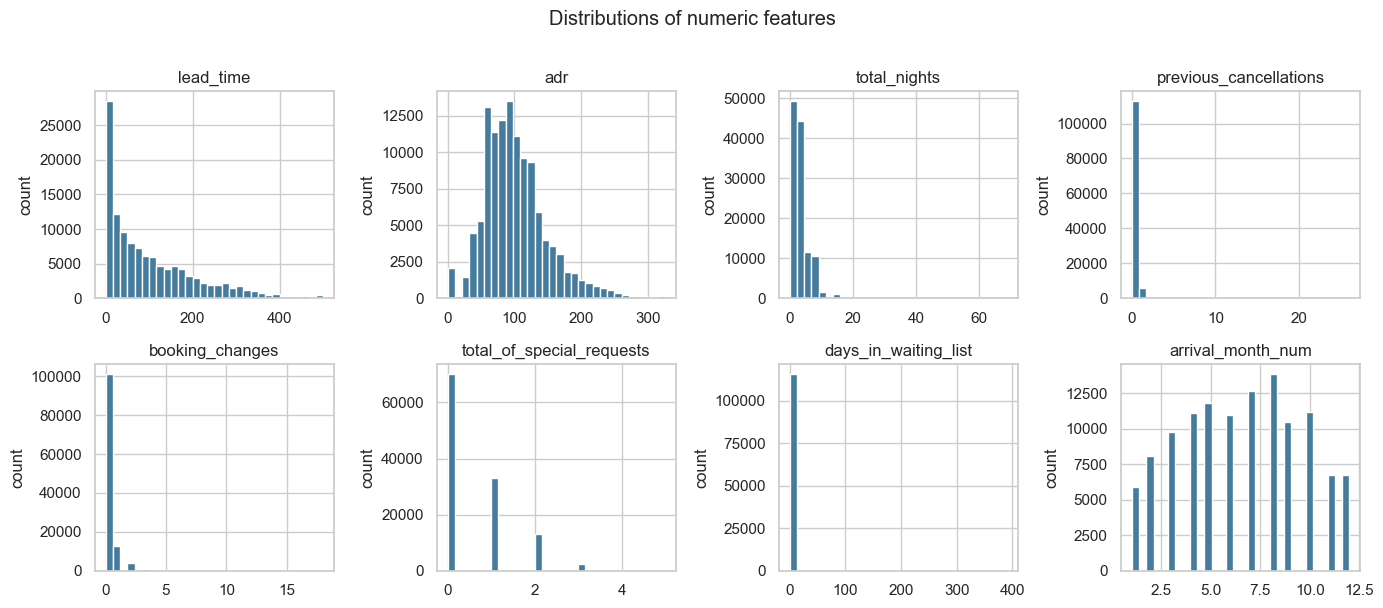

In [17]:
numeric_to_plot = ['lead_time', 'adr', 'total_nights',
                   'previous_cancellations', 'booking_changes',
                   'total_of_special_requests',
                   'days_in_waiting_list', 'arrival_month_num']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, numeric_to_plot):
    series = df[col]
    if col == 'lead_time':
        series = series.clip(upper=500)
    ax.hist(series, bins=30, color='#457b9d', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('count')
fig.suptitle('Distributions of numeric features', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES / 'numeric_histograms.png')
plt.show()

### 7.2 Categorical features

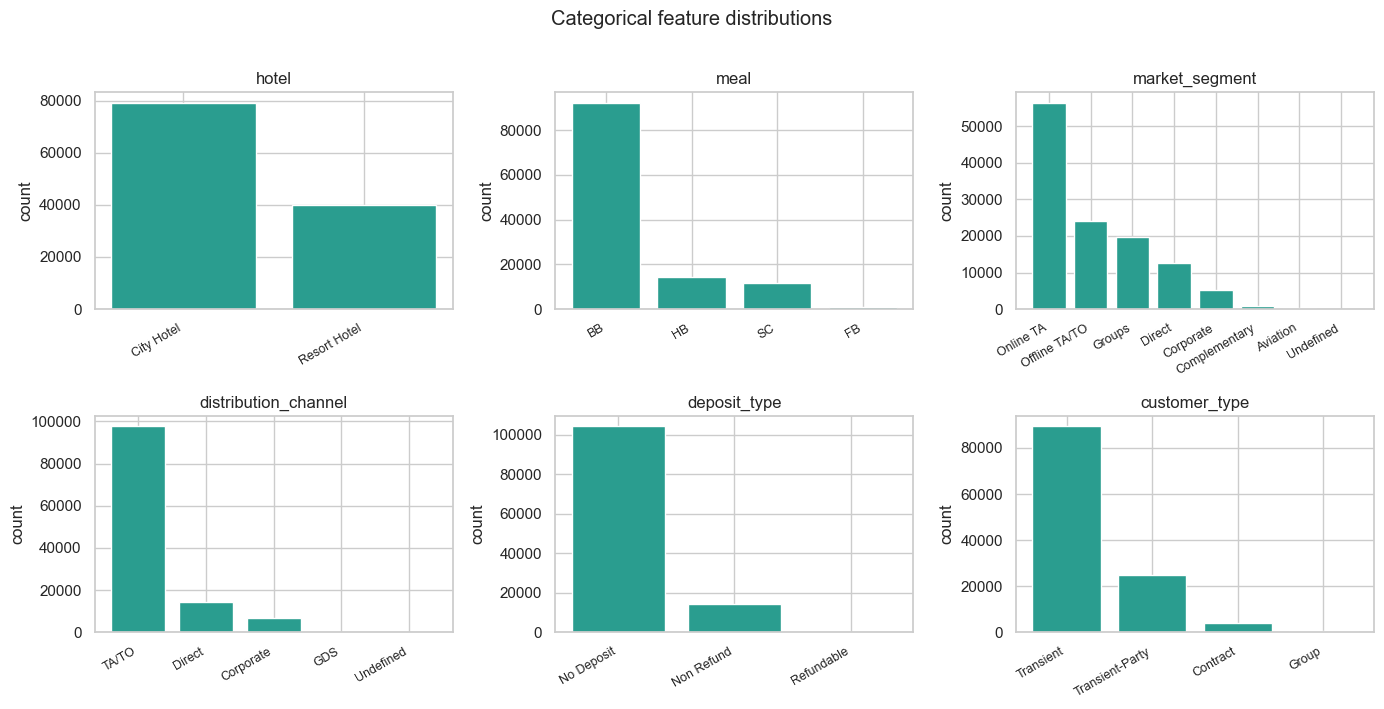

In [18]:
cat_to_plot = ['hotel', 'meal', 'market_segment',
               'distribution_channel', 'deposit_type', 'customer_type']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, cat_to_plot):
    counts = df[col].value_counts()
    ax.bar(range(len(counts)), counts.values, color='#2a9d8f')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(col)
    ax.set_ylabel('count')
fig.suptitle('Categorical feature distributions', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES / 'categorical_distributions.png')
plt.show()

## 8. Bivariate EDA - what predicts cancellation?

### 8.1 Cancellation rate by category

Overall cancellation rate: 37.08%


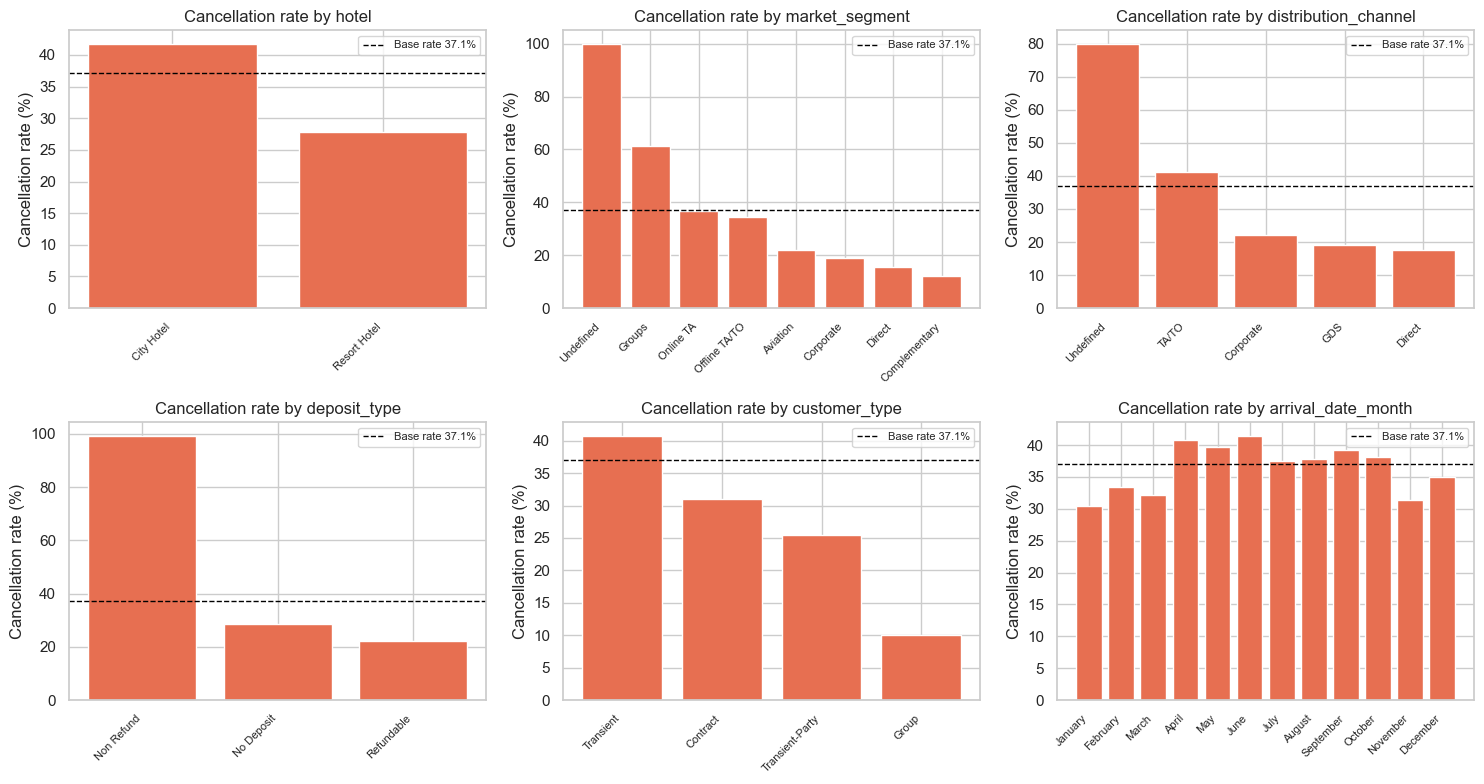

In [19]:
BASE_RATE = df['is_canceled'].mean()
print(f'Overall cancellation rate: {BASE_RATE*100:.2f}%')

rate_cols = ['hotel', 'market_segment', 'distribution_channel',
             'deposit_type', 'customer_type', 'arrival_date_month']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, rate_cols):
    rate = df.groupby(col, observed=True)['is_canceled'].mean()
    if col == 'arrival_date_month':
        rate = rate.reindex(month_order)
    else:
        rate = rate.sort_values(ascending=False)
    ax.bar(range(len(rate)), rate.values * 100, color='#e76f51')
    ax.axhline(BASE_RATE * 100, color='black', linestyle='--', linewidth=1,
               label=f'Base rate {BASE_RATE*100:.1f}%')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Cancellation rate by {col}')
    ax.set_ylabel('Cancellation rate (%)')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(IMAGES / 'cancellation_rate_by_category.png')
plt.show()

### 8.2 Numeric features split by target

Lead time is the standout - the longer ahead a booking is made, the more likely it is to be canceled.

C:\Users\aeh12\AppData\Local\Temp\ipykernel_69140\3341443042.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled'])
C:\Users\aeh12\AppData\Local\Temp\ipykernel_69140\3341443042.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled'])
C:\Users\aeh12\AppData\Local\Temp\ipykernel_69140\3341443042.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled'])
C:\Users\aeh12\AppData\Local\Temp\ipykernel_69140\3341443042.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled'])
C:\Users\aeh12\AppData\Local\Temp\ipykernel_6914

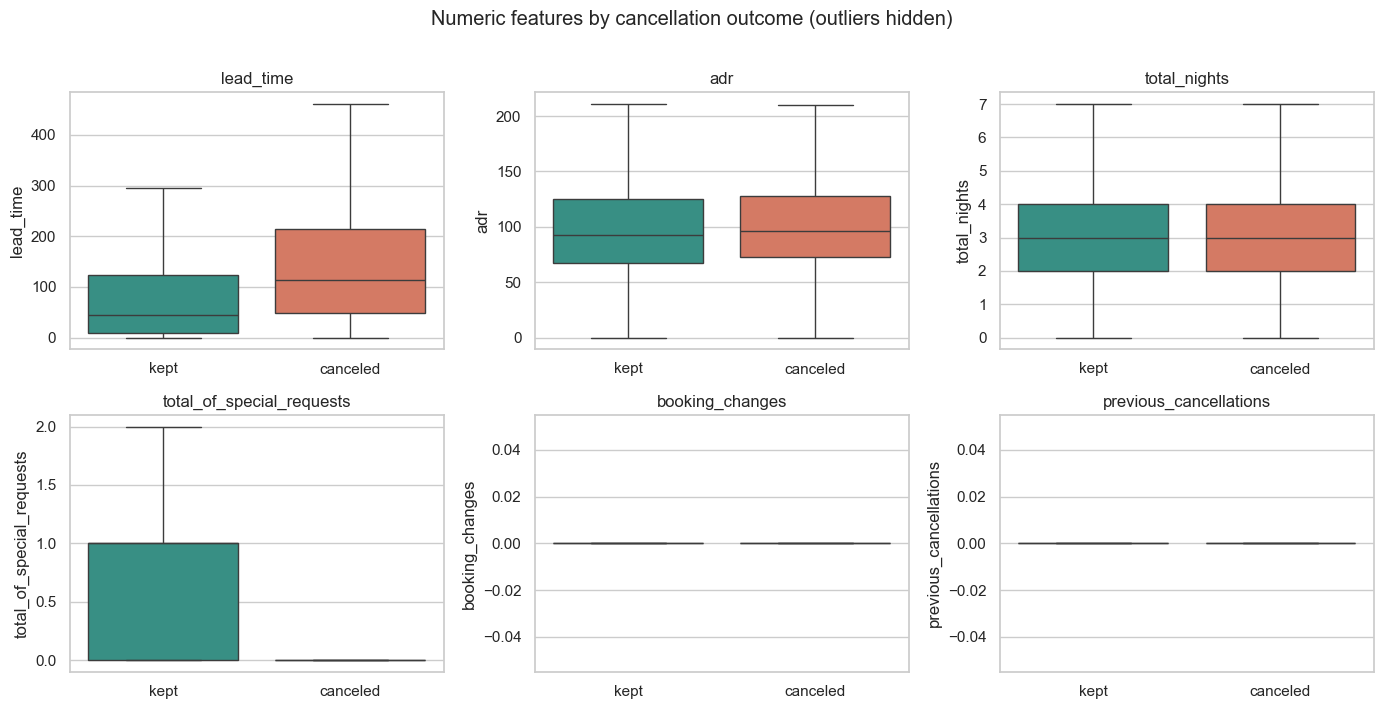

In [20]:
split_cols = ['lead_time', 'adr', 'total_nights',
              'total_of_special_requests', 'booking_changes',
              'previous_cancellations']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, split_cols):
    sns.boxplot(x='is_canceled', y=col, data=df, order=[0, 1],
                palette=['#2a9d8f', '#e76f51'], ax=ax,
                showfliers=False)
    ax.set_xticklabels(['kept', 'canceled'])
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Numeric features by cancellation outcome (outliers hidden)', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES / 'numeric_by_target.png')
plt.show()

### 8.3 The `deposit_type` story

Conventional intuition says a non-refundable deposit should make a guest *less* likely to cancel - they would lose their money. The data shows the opposite. This is a known quirk of the dataset and worth investigating before building the model.

              bookings  cancel_rate
deposit_type                       
No Deposit      104460         28.4
Non Refund       14587         99.4
Refundable         162         22.2


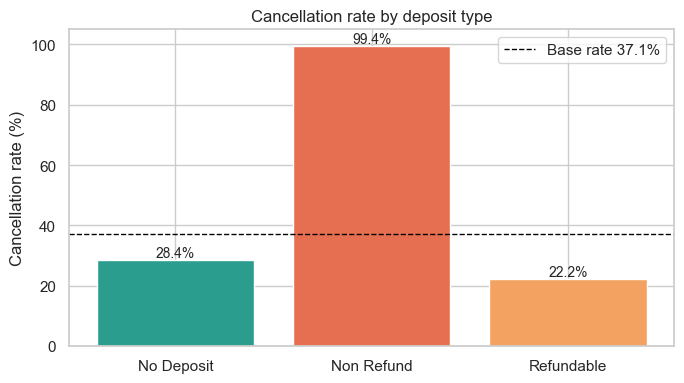


The Non Refund segment cancels at >99%. Likely either an artifact
of how the booking system records refused/voided reservations,
or it is dominated by a single tour operator with a refund agreement
outside the visible booking record. Either way the model will use
this signal but the README flags it as a caveat for stakeholders.


In [21]:
deposit_view = (df.groupby('deposit_type', observed=True)
                  .agg(bookings=('is_canceled', 'size'),
                       cancel_rate=('is_canceled', 'mean'))
                  .assign(cancel_rate=lambda d: (d['cancel_rate']*100).round(1))
                  .sort_values('bookings', ascending=False))
print(deposit_view)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(deposit_view.index, deposit_view['cancel_rate'],
       color=['#2a9d8f', '#e76f51', '#f4a261'])
ax.axhline(BASE_RATE * 100, color='black', linestyle='--', linewidth=1,
           label=f'Base rate {BASE_RATE*100:.1f}%')
for i, (k, v) in enumerate(zip(deposit_view.index, deposit_view['cancel_rate'])):
    ax.text(i, v + 1, f'{v}%', ha='center', fontsize=10)
ax.set_title('Cancellation rate by deposit type')
ax.set_ylabel('Cancellation rate (%)')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES / 'deposit_type_paradox.png')
plt.show()

print('\nThe Non Refund segment cancels at >99%. Likely either an artifact')
print('of how the booking system records refused/voided reservations,')
print('or it is dominated by a single tour operator with a refund agreement')
print('outside the visible booking record. Either way the model will use')
print('this signal but the README flags it as a caveat for stakeholders.')

### 8.4 Lead time vs cancellation - the strongest single signal

             bookings  cancel_rate
lead_bucket                       
0-7d            19635         9.60
8-30d           18945        27.89
31-90d          29529        37.73
91-180d         26420        44.74
181-365d        21533        55.46
365d+            3147        67.65


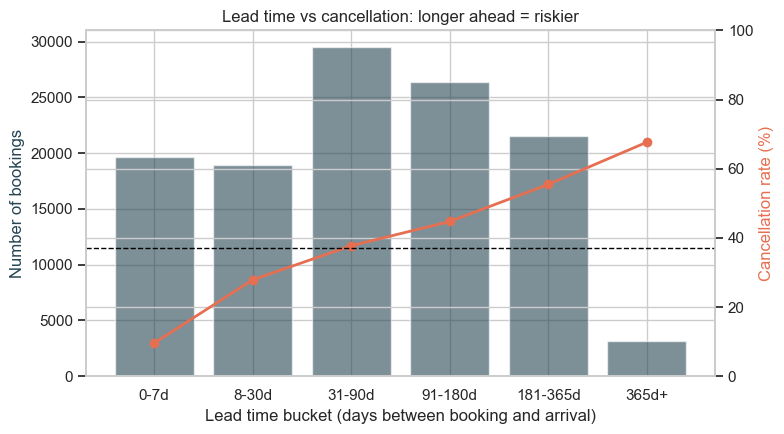

In [22]:
df['lead_bucket'] = pd.cut(df['lead_time'],
                           bins=[-1, 7, 30, 90, 180, 365, 1000],
                           labels=['0-7d', '8-30d', '31-90d',
                                   '91-180d', '181-365d', '365d+'])
lead_view = (df.groupby('lead_bucket', observed=True)
               .agg(bookings=('is_canceled', 'size'),
                    cancel_rate=('is_canceled', 'mean')))
lead_view['cancel_rate'] *= 100
print(lead_view.round(2))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(lead_view.index.astype(str), lead_view['bookings'], color='#264653', alpha=0.6)
ax1.set_ylabel('Number of bookings', color='#264653')
ax1.set_xlabel('Lead time bucket (days between booking and arrival)')
ax2 = ax1.twinx()
ax2.plot(lead_view.index.astype(str), lead_view['cancel_rate'],
         color='#e76f51', marker='o', linewidth=2, label='Cancellation rate')
ax2.axhline(BASE_RATE * 100, color='black', linestyle='--', linewidth=1)
ax2.set_ylabel('Cancellation rate (%)', color='#e76f51')
ax2.set_ylim(0, 100)
ax1.set_title('Lead time vs cancellation: longer ahead = riskier')
plt.tight_layout()
plt.savefig(IMAGES / 'lead_time_effect.png')
plt.show()

### 8.5 Cancellation trend over time

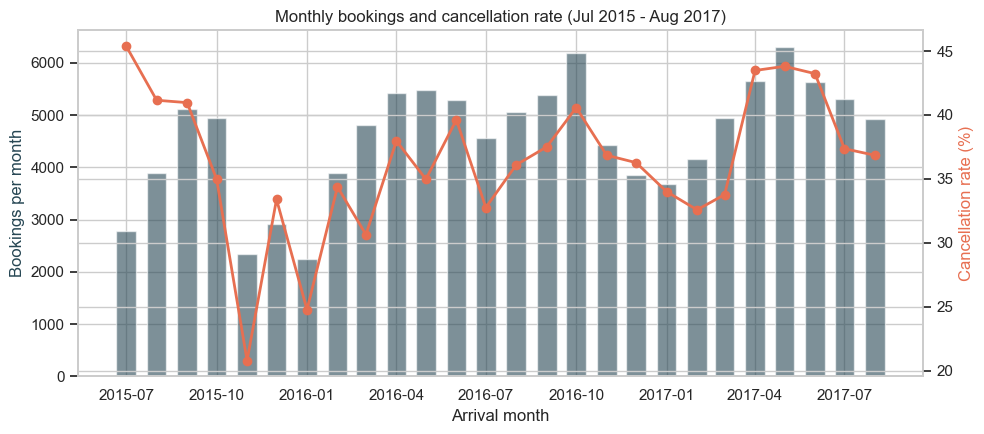

In [23]:
monthly = (df.set_index('arrival_date')
             .resample('MS')['is_canceled']
             .agg(['size', 'mean'])
             .rename(columns={'size': 'bookings', 'mean': 'cancel_rate'}))
monthly['cancel_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly.index, monthly['bookings'], width=20, color='#264653', alpha=0.6,
        label='Bookings')
ax1.set_ylabel('Bookings per month', color='#264653')
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['cancel_rate'], color='#e76f51',
         marker='o', linewidth=2, label='Cancellation rate')
ax2.set_ylabel('Cancellation rate (%)', color='#e76f51')
ax1.set_title('Monthly bookings and cancellation rate (Jul 2015 - Aug 2017)')
ax1.set_xlabel('Arrival month')
plt.tight_layout()
plt.savefig(IMAGES / 'time_trend.png')
plt.show()

### 8.6 Correlation among numeric features

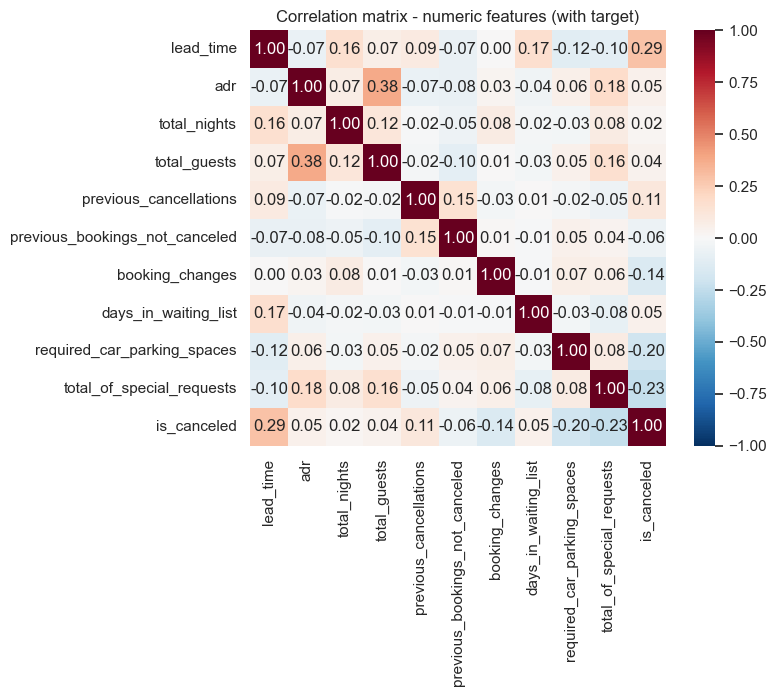

In [24]:
num_cols_for_corr = ['lead_time', 'adr', 'total_nights', 'total_guests',
                     'previous_cancellations', 'previous_bookings_not_canceled',
                     'booking_changes', 'days_in_waiting_list',
                     'required_car_parking_spaces', 'total_of_special_requests',
                     'is_canceled']
corr = df[num_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation matrix - numeric features (with target)')
plt.tight_layout()
plt.savefig(IMAGES / 'correlation_heatmap.png')
plt.show()

## 9. Train/test split and preprocessing pipeline

Stratified 80/20 split on `is_canceled`. The preprocessing is wrapped in a `Pipeline` so it is fit only on training data - this prevents the held-out test set from leaking through scaler statistics or one-hot vocabularies.

In [25]:
X = df[MODEL_FEATURES].copy()
y = df['is_canceled'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, positives: {y_train.sum():,} '
      f'({y_train.mean()*100:.2f}%)')
print(f'Test:  {X_test.shape}, positives: {y_test.sum():,} '
      f'({y_test.mean()*100:.2f}%)')

Train: (95367, 29), positives: 35,359 (37.08%)
Test:  (23842, 29), positives: 8,840 (37.08%)


In [26]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ],
    remainder='drop',
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 10. Baseline model: Logistic Regression

Logistic Regression is the natural baseline - covered in Module 13, interpretable, and a fair reference point for the tree-based models we will add in Module 24. We use `class_weight='balanced'` to nudge the model toward the minority (canceled) class, and compare against a `DummyClassifier` so any reported accuracy is honest.

In [27]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f'DummyClassifier (predict majority) test accuracy: {dummy_acc:.4f}')

DummyClassifier (predict majority) test accuracy: 0.6292


In [28]:
logreg = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(logreg, X_train, y_train, cv=cv,
                         scoring='roc_auc', n_jobs=-1)
print(f'5-fold CV ROC-AUC on train: {cv_auc.mean():.4f} '
      f'+/- {cv_auc.std():.4f}')

logreg.fit(X_train, y_train)
test_proba = logreg.predict_proba(X_test)[:, 1]
test_pred = logreg.predict(X_test)

5-fold CV ROC-AUC on train: 0.9081 +/- 0.0019


## 11. Evaluation - metric rationale and interpretation

**Primary metric: ROC-AUC.** The target is imbalanced (37% positive), and revenue management does not need a hard yes/no per booking - they need a *risk score* per booking that they can use to decide overbooking levels. ROC-AUC measures how well the model ranks bookings by risk, which is exactly what the team will consume.

**Secondary metrics:** average precision (PR-AUC), precision/recall/F1 at the default 0.5 threshold, the precision-recall curve, the confusion matrix, and a cumulative-gains chart for the business framing.

In [29]:
auc = roc_auc_score(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)
acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred)
rec = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

results = pd.DataFrame({
    'metric': ['ROC-AUC', 'Average precision (PR-AUC)',
               'Accuracy', 'Precision (canceled)',
               'Recall (canceled)', 'F1 (canceled)',
               'Dummy accuracy (baseline)'],
    'value':  [auc, ap, acc, prec, rec, f1, dummy_acc],
})
results['value'] = results['value'].round(4)
print(results.to_string(index=False))

                    metric  value
                   ROC-AUC 0.9079
Average precision (PR-AUC) 0.8661
                  Accuracy 0.8223
      Precision (canceled) 0.7337
         Recall (canceled) 0.8174
             F1 (canceled) 0.7733
 Dummy accuracy (baseline) 0.6292


In [30]:
print(classification_report(y_test, test_pred,
                            target_names=['kept', 'canceled']))

              precision    recall  f1-score   support

        kept       0.88      0.83      0.85     15002
    canceled       0.73      0.82      0.77      8840

    accuracy                           0.82     23842
   macro avg       0.81      0.82      0.81     23842
weighted avg       0.83      0.82      0.82     23842



### 11.1 ROC and Precision-Recall curves

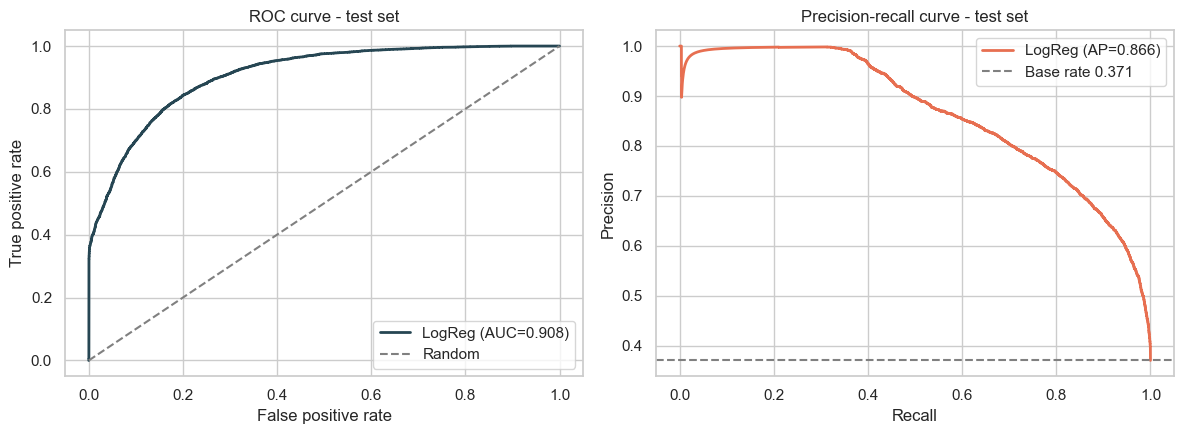

In [31]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, color='#264653', linewidth=2,
             label=f'LogReg (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve - test set')
axes[0].legend(loc='lower right')

axes[1].plot(rec_curve, prec_curve, color='#e76f51', linewidth=2,
             label=f'LogReg (AP={ap:.3f})')
axes[1].axhline(BASE_RATE, color='gray', linestyle='--',
                label=f'Base rate {BASE_RATE:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-recall curve - test set')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(IMAGES / 'roc_pr_curves.png')
plt.show()

### 11.2 Confusion matrix

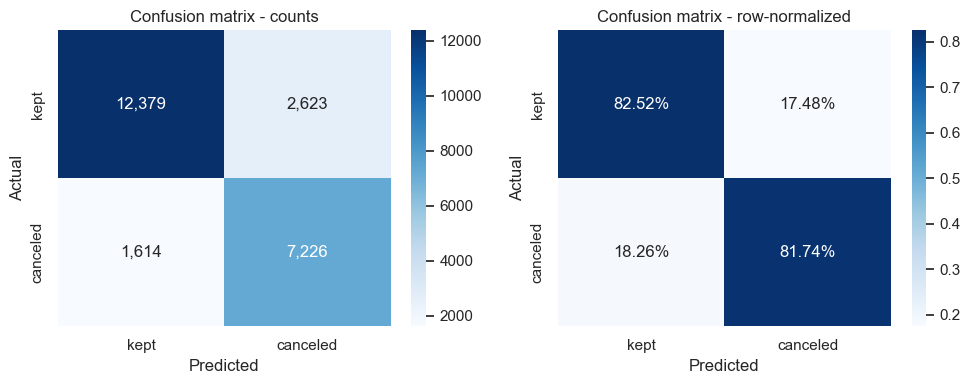

In [32]:
cm = confusion_matrix(y_test, test_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['kept', 'canceled'],
            yticklabels=['kept', 'canceled'], ax=axes[0])
axes[0].set_title('Confusion matrix - counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['kept', 'canceled'],
            yticklabels=['kept', 'canceled'], ax=axes[1])
axes[1].set_title('Confusion matrix - row-normalized')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig(IMAGES / 'confusion_matrix.png')
plt.show()

### 11.3 Business framing - cumulative gains

If revenue management focuses overbooking attention on the bookings the model flags as highest risk, what fraction of actual cancellations do they cover at each cutoff?

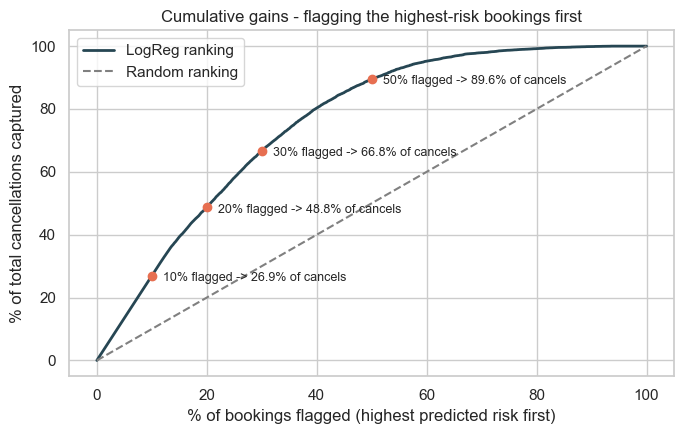

In [33]:
scored = pd.DataFrame({'proba': test_proba, 'y': y_test.values})
scored = scored.sort_values('proba', ascending=False).reset_index(drop=True)
scored['cum_canc'] = scored['y'].cumsum()
scored['pct_flagged'] = (np.arange(1, len(scored) + 1) / len(scored)) * 100
scored['pct_canc_captured'] = scored['cum_canc'] / scored['y'].sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(scored['pct_flagged'], scored['pct_canc_captured'],
        color='#264653', linewidth=2, label='LogReg ranking')
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', label='Random ranking')
for pct in (10, 20, 30, 50):
    captured = scored.loc[scored['pct_flagged'] >= pct, 'pct_canc_captured'].iloc[0]
    ax.scatter([pct], [captured], color='#e76f51', zorder=5)
    ax.annotate(f'{pct}% flagged -> {captured:.1f}% of cancels',
                (pct, captured), textcoords='offset points',
                xytext=(8, -4), fontsize=9)
ax.set_xlabel('% of bookings flagged (highest predicted risk first)')
ax.set_ylabel('% of total cancellations captured')
ax.set_title('Cumulative gains - flagging the highest-risk bookings first')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES / 'cumulative_gains.png')
plt.show()

### 11.4 Top coefficients

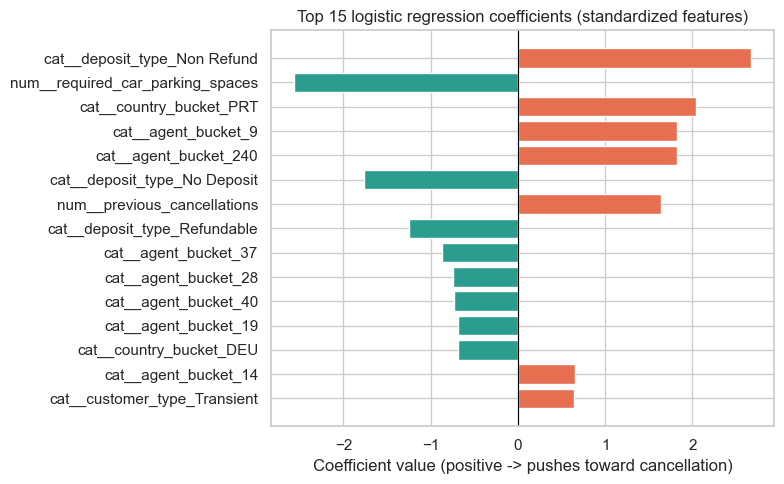

Top 10 by absolute weight:
                         feature      coef
    cat__deposit_type_Non Refund  2.673633
num__required_car_parking_spaces -2.564126
         cat__country_bucket_PRT  2.045675
             cat__agent_bucket_9  1.819340
           cat__agent_bucket_240  1.818037
    cat__deposit_type_No Deposit -1.762906
     num__previous_cancellations  1.643175
    cat__deposit_type_Refundable -1.249663
            cat__agent_bucket_37 -0.868326
            cat__agent_bucket_28 -0.739111


In [34]:
fitted_pre = logreg.named_steps['preprocess']
feature_names = fitted_pre.get_feature_names_out()
coefs = logreg.named_steps['clf'].coef_[0]

coef_df = (pd.DataFrame({'feature': feature_names, 'coef': coefs})
             .assign(abs_coef=lambda d: d['coef'].abs())
             .sort_values('abs_coef', ascending=False))

top = coef_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e76f51' if c > 0 else '#2a9d8f' for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 logistic regression coefficients (standardized features)')
ax.set_xlabel('Coefficient value (positive -> pushes toward cancellation)')
plt.tight_layout()
plt.savefig(IMAGES / 'top_coefficients.png')
plt.show()

print('Top 10 by absolute weight:')
print(coef_df.head(10)[['feature', 'coef']].to_string(index=False))

## 12. Findings summary

Key takeaways from the EDA and the baseline model (numbers come from the cells above):

1. **Cancellation rate is 37%** - imbalanced enough to make accuracy misleading, but mild compared with classic fraud or churn problems. The dummy 'predict no cancel' baseline already scores ~63% accuracy.
2. **`reservation_status` and `reservation_status_date` are leakage** and were excluded from the model. They literally describe whether the booking was canceled.
3. **Lead time is the strongest single signal** - bookings made 180+ days before arrival cancel at well over twice the base rate, while bookings made within a week of arrival rarely cancel.
4. **`deposit_type = Non Refund` cancels at >99%** - counter-intuitive and worth flagging for stakeholders. Most likely a quirk of how the booking system records voided/refused reservations or a single tour operator with an outside-the-record refund agreement.
5. **Channel and segment matter:** city-hotel bookings cancel more than resort-hotel bookings; market segment 'Groups' cancels far more than 'Direct' or 'Corporate'.

The cumulative-gains chart is the clearest business story: the team can focus overbooking attention on the top-flagged bookings and still cover most real cancellations, with a clear lift over random treatment.

## 13. Next steps (Module 24)

- Add tree-based comparators: Decision Tree (Mod 14), Random Forest (Mod 20), and Gradient Boosting. The published Antonio et al. paper reports ROC-AUC > 0.90 with random forests, so there is real headroom above the baseline.
- Tune the decision threshold using the hotel's actual cost ratio: the cost of an overbooked walked-guest event vs. the cost of an empty room.
- Investigate the `Non Refund` deposit-type result with the data owner before any deployment recommendation - a model that depends on it without explanation is a liability.
- Explore time-based train/test splits (train on 2015-2016, test on 2017) to check whether the model holds up out-of-time, not just out-of-sample.